In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [4]:
np.random.seed(42)

weeks = 120

data = pd.DataFrame({
"TV_A":np.random.uniform(100,300,weeks),
"Digital_A":np.random.uniform(50,200,weeks),
"Radio_A":np.random.uniform(20,100,weeks),
"Price_A":np.random.uniform(9,12,weeks),
"TV_B":np.random.uniform(80,250,weeks),
"Digital_B":np.random.uniform(40,180,weeks),
"Radio_B":np.random.uniform(20,100,weeks),
"Price_B":np.random.uniform(9,12,weeks),
})
print(data.head())


data["Seasonality"] = np.sin(np.arange(weeks)/6)

         TV_A   Digital_A    Radio_A    Price_A        TV_B  Digital_B  \
0  174.908024  171.116023  95.236687  10.164510  186.997768  63.650909   
1  290.142861  184.413695  96.314286  10.929865  198.277277  79.002647   
2  246.398788   97.700521  93.189151  10.374759  157.271981  64.781468   
3  219.731697   66.507789  49.612696  10.636850  186.684874  52.418355   
4  131.203728   84.190274  21.236529  11.824394  179.333433  56.889022   

     Radio_B    Price_B  
0  95.067237   9.039283  
1  34.498645  10.990612  
2  25.319701   9.534108  
3  79.289652  11.883211  
4  65.957849   9.445988  


In [5]:
data["Sales_A"]=(
5
+0.04*data["TV_A"]
+0.06*data["Digital_A"]
+0.03*data["Radio_A"]
-0.03*data["TV_B"]
-0.04*data["Digital_B"]
-0.8*data["Price_A"]
+2*data["Seasonality"]
+np.random.normal(0,2,weeks)
)

data["Sales_B"]=(
5
+0.03*data["TV_B"]
+0.05*data["Digital_B"]
-0.02*data["TV_A"]
-0.7*data["Price_B"]
+1.5*data["Seasonality"]
+np.random.normal(0,2,weeks)
)

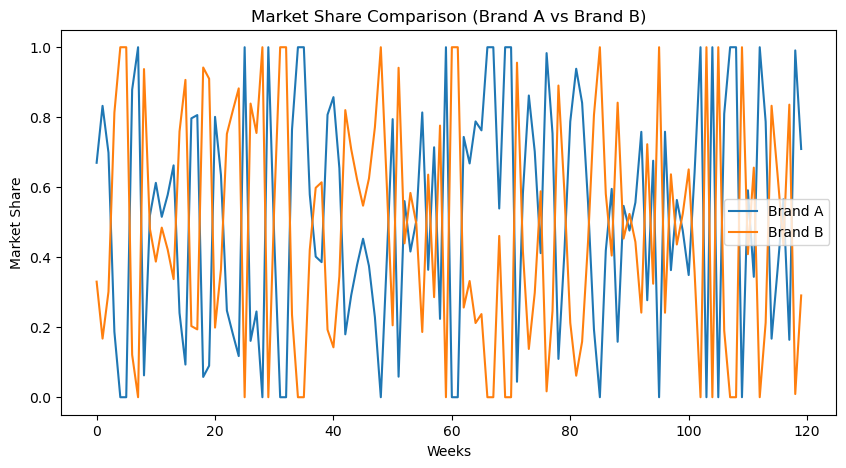

In [19]:
data["MarketShare_A"] = data["Sales_A"] / (data["Sales_A"] + data["Sales_B"])
data["MarketShare_B"] = data["Sales_B"] / (data["Sales_A"] + data["Sales_B"])
data["MarketShare_A"] = np.clip(data["MarketShare_A"],0,1)
data["MarketShare_B"] = np.clip(data["MarketShare_B"],0,1)
plt.figure(figsize=(10,5))

plt.plot(data["MarketShare_A"], label="Brand A")
plt.plot(data["MarketShare_B"], label="Brand B")

plt.title("Market Share Comparison (Brand A vs Brand B)")
plt.xlabel("Weeks")
plt.ylabel("Market Share")

plt.legend()

plt.show()


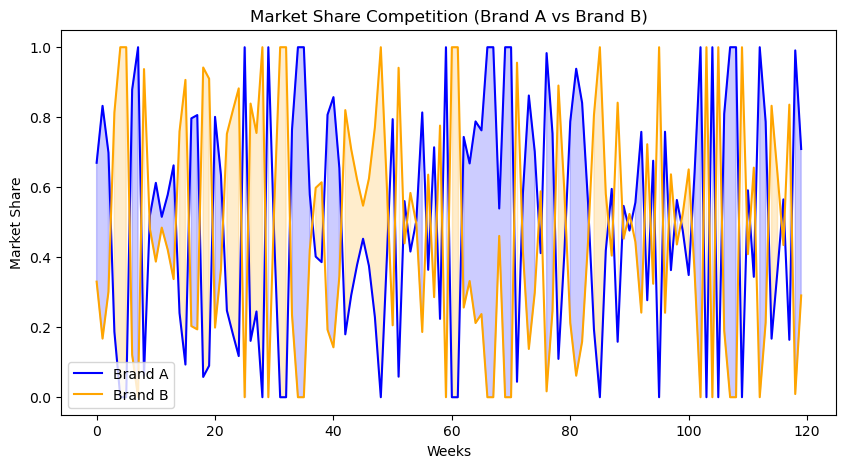

In [21]:
plt.figure(figsize=(10,5))

plt.plot(data["MarketShare_A"], label="Brand A", color="blue")
plt.plot(data["MarketShare_B"], label="Brand B", color="orange")

# Highlight dominance
plt.fill_between(
    range(len(data)),
    data["MarketShare_A"],
    data["MarketShare_B"],
    where=(data["MarketShare_A"] > data["MarketShare_B"]),
    color="blue",
    alpha=0.2
)

plt.fill_between(
    range(len(data)),
    data["MarketShare_A"],
    data["MarketShare_B"],
    where=(data["MarketShare_B"] > data["MarketShare_A"]),
    color="orange",
    alpha=0.2
)

plt.title("Market Share Competition (Brand A vs Brand B)")
plt.xlabel("Weeks")
plt.ylabel("Market Share")

plt.legend()

plt.show()

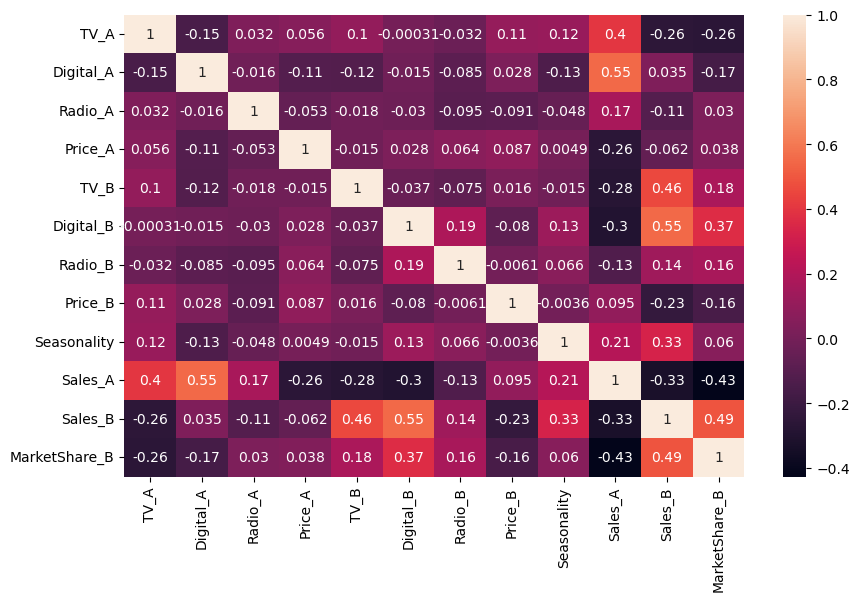

In [9]:

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True)
plt.show()

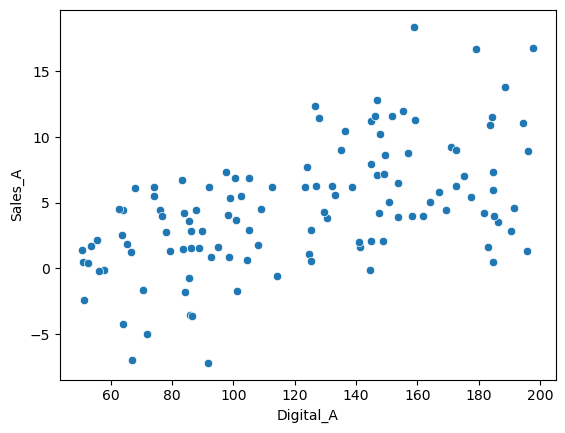

In [352]:



sns.scatterplot(x=data["Digital_A"],y=data["Sales_A"])
plt.show()


In [23]:
def adstock(x,decay):

    result=[]

    for i in range(len(x)):

        if i==0:
            result.append(x[i])
        else:
            result.append(x[i]+decay*result[i-1])

    return result

data["TV_A_adstock"]=adstock(data["TV_A"],0.5)
data["Digital_A_adstock"]=adstock(data["Digital_A"],0.4)
data["Radio_A_adstock"]=adstock(data["Radio_A"],0.3)

import pandas as pd
import statsmodels.api as sm

# Features
X = data[[
"TV_A_adstock",
"Digital_A_adstock",
"Radio_A_adstock",
"TV_B",
"Digital_B",
"Price_A",
"Seasonality"
]]

# Target
y = data["Sales_A"]

# Add constant
X = sm.add_constant(X)

# Model
model = sm.OLS(y, X).fit()

# Simple Output
results = pd.DataFrame({
"Variable": model.params.index,
"Coefficient": model.params.values,
"P_value": model.pvalues.values
})

print("R_squared:", model.rsquared)
print("Adjusted_R_squared:", model.rsquared_adj)

print("\nRegression Results:")
print(results)

R_squared: 0.7346637869306208
Adjusted_R_squared: 0.7180802736137846

Regression Results:
            Variable  Coefficient       P_value
0              const    -5.479536  1.322014e-01
1       TV_A_adstock     0.028537  8.364777e-14
2  Digital_A_adstock     0.062228  2.160399e-21
3    Radio_A_adstock     0.037809  5.521416e-05
4               TV_B    -0.021670  5.817902e-06
5          Digital_B    -0.040209  6.043225e-10
6            Price_A    -0.866345  4.206878e-04
7        Seasonality     1.940345  6.653733e-08


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif=pd.DataFrame()

vif["variable"]=X.columns
vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

print(vif)

            variable         VIF
0              const  257.658939
1       TV_A_adstock    1.108594
2  Digital_A_adstock    1.135710
3    Radio_A_adstock    1.024521
4               TV_B    1.022553
5          Digital_B    1.023854
6            Price_A    1.023422
7        Seasonality    1.080120


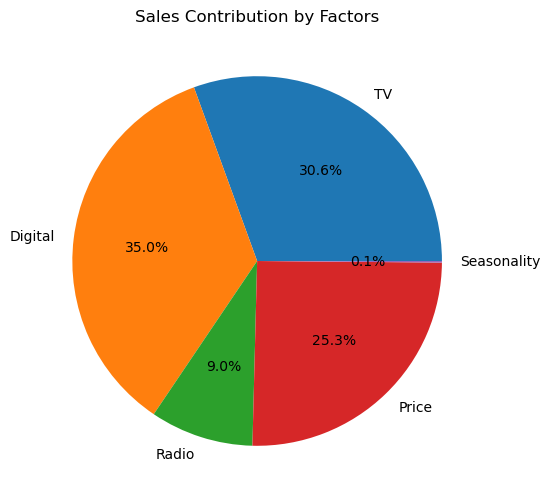

In [31]:
coeff = model.params

contribution_tv = abs((coeff["TV_A_adstock"] * data["TV_A_adstock"]).sum())
contribution_digital = abs((coeff["Digital_A_adstock"] * data["Digital_A_adstock"]).sum())
contribution_radio = abs((coeff["Radio_A_adstock"] * data["Radio_A_adstock"]).sum())
contribution_price = abs((coeff["Price_A"] * data["Price_A"]).sum())
contribution_season = abs((coeff["Seasonality"] * data["Seasonality"]).sum())

labels = ["TV","Digital","Radio","Price","Seasonality"]

values = [
contribution_tv,
contribution_digital,
contribution_radio,
contribution_price,
contribution_season
]

plt.figure(figsize=(6,6))
plt.pie(values,labels=labels,autopct="%1.1f%%")
plt.title("Sales Contribution by Factors")
plt.show()



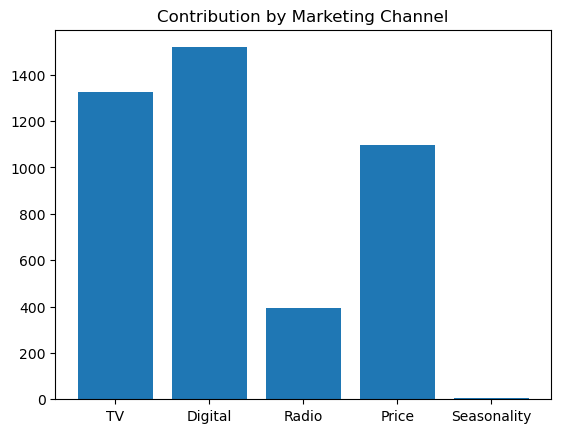

In [33]:
plt.bar(labels,values)
plt.title("Contribution by Marketing Channel")
plt.show()

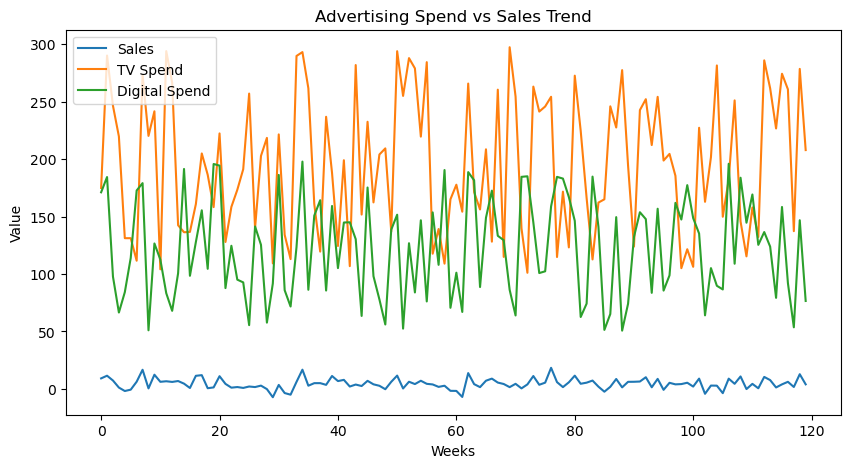

In [35]:
plt.figure(figsize=(10,5))

plt.plot(data["Sales_A"], label="Sales")
plt.plot(data["TV_A"], label="TV Spend")
plt.plot(data["Digital_A"], label="Digital Spend")

plt.legend()
plt.title("Advertising Spend vs Sales Trend")
plt.xlabel("Weeks")
plt.ylabel("Value")

plt.show()

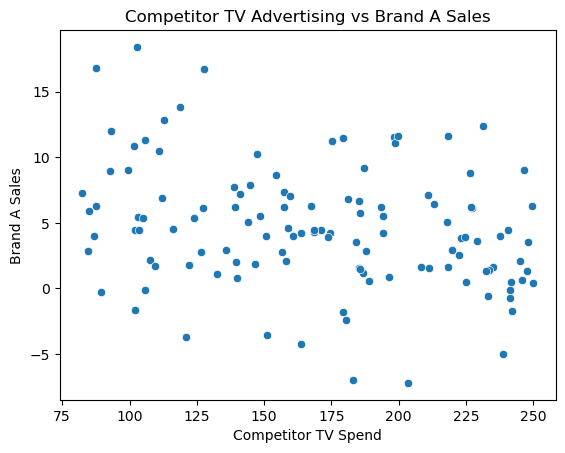

In [37]:
sns.scatterplot(x=data["TV_B"], y=data["Sales_A"])

plt.title("Competitor TV Advertising vs Brand A Sales")
plt.xlabel("Competitor TV Spend")
plt.ylabel("Brand A Sales")

plt.show()

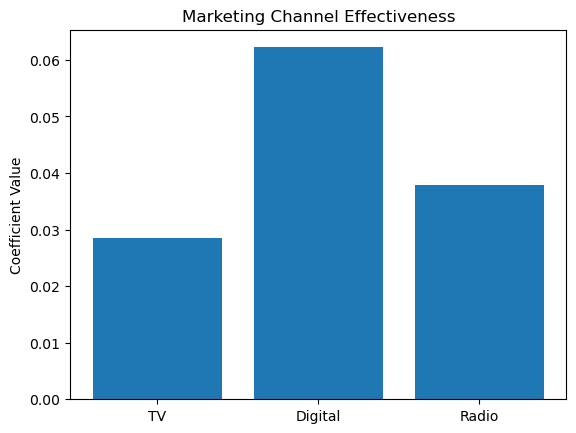

In [39]:
channels = ["TV","Digital","Radio"]

roi_values = [
model.params["TV_A_adstock"],
model.params["Digital_A_adstock"],
model.params["Radio_A_adstock"]
]

plt.bar(channels,roi_values)

plt.title("Marketing Channel Effectiveness")
plt.ylabel("Coefficient Value")

plt.show()

In [41]:
base_sales = abs(model.params["const"] * len(data))

print("Base Revenue Contribution:", base_sales)

Base Revenue Contribution: 657.5443259866712


In [43]:
tv_rev = (model.params["TV_A_adstock"] * data["TV_A_adstock"]).sum()
digital_rev = (model.params["Digital_A_adstock"] * data["Digital_A_adstock"]).sum()
radio_rev = (model.params["Radio_A_adstock"] * data["Radio_A_adstock"]).sum()

marketing_revenue = tv_rev + digital_rev + radio_rev

print("Marketing Driven Revenue:", marketing_revenue)

Marketing Driven Revenue: 3236.3702864460097


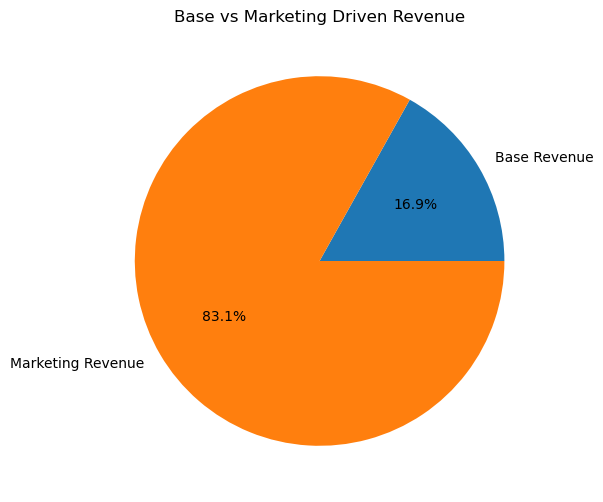

In [45]:
 labels = ["Base Revenue","Marketing Revenue"]

values = [
abs(base_sales),
abs(marketing_revenue)
]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.1f%%")

plt.title("Base vs Marketing Driven Revenue")

plt.show()

TV Spend: 23450.641988390045
Digital Spend: 14702.38942227891
Radio Spend: 7293.49865928818


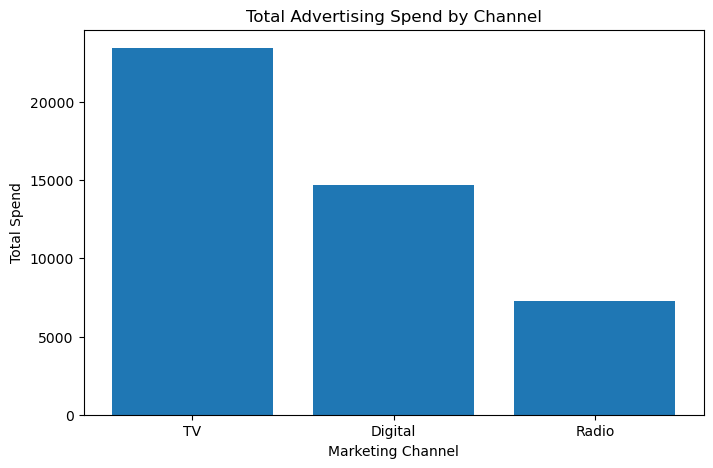

In [47]:
total_tv_spend = data["TV_A"].sum()
total_digital_spend = data["Digital_A"].sum()
total_radio_spend = data["Radio_A"].sum()

print("TV Spend:", total_tv_spend)
print("Digital Spend:", total_digital_spend)
print("Radio Spend:", total_radio_spend)

import matplotlib.pyplot as plt

channels = ["TV", "Digital", "Radio"]

spend_values = [
total_tv_spend,
total_digital_spend,
total_radio_spend
]

plt.figure(figsize=(8,5))

plt.bar(channels, spend_values)

plt.title("Total Advertising Spend by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Spend")

plt.show()

In [49]:
tv_sales = model.params.get("TV_A_adstock",0) * data["TV_A_adstock"]
digital_sales = model.params.get("Digital_A_adstock",0) * data["Digital_A_adstock"]
radio_sales = model.params.get("Radio_A_adstock",0) * data["Radio_A_adstock"]

tv_sales = tv_sales.sum()
digital_sales = digital_sales.sum()
radio_sales = radio_sales.sum()

print("TV Sales Impact:", tv_sales)
print("Digital Sales Impact:", digital_sales)
print("Radio Sales Impact:", radio_sales)

TV Sales Impact: 1325.6907128540338
Digital Sales Impact: 1518.3899836196679
Radio Sales Impact: 392.28958997230785


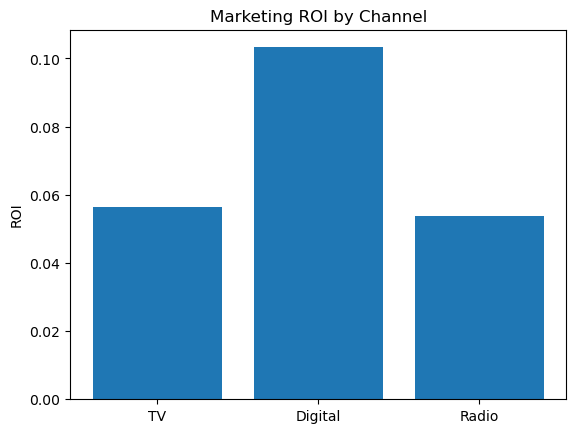

In [60]:
# ROI calculation
roi_tv = contribution_tv / data["TV_A"].sum()
roi_digital = contribution_digital / data["Digital_A"].sum()
roi_radio = contribution_radio / data["Radio_A"].sum()

# Channels
channels = ["TV","Digital","Radio"]

# ROI values
roi_values = [
    roi_tv,
    roi_digital,
    roi_radio
]

# Plot
plt.bar(channels, roi_values)

plt.title("Marketing ROI by Channel")
plt.ylabel("ROI")

plt.show()

In [62]:
data["Predicted_Sales"] = model.predict(X)

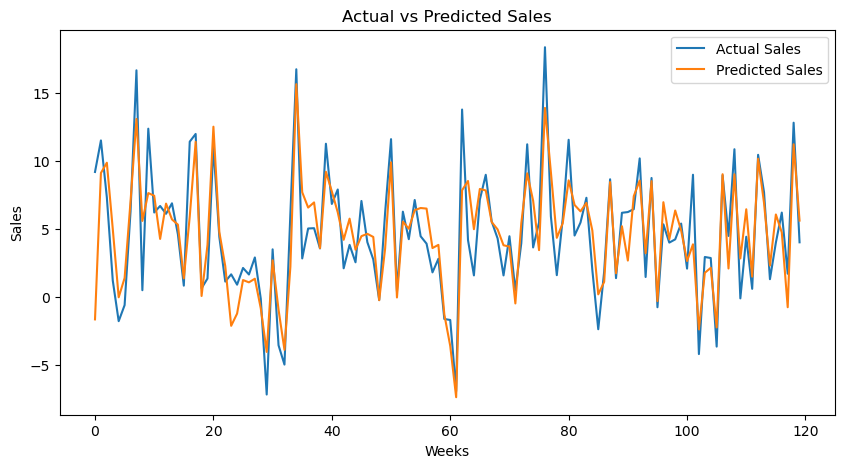

In [64]:
plt.figure(figsize=(10,5))

plt.plot(data["Sales_A"], label="Actual Sales")
plt.plot(data["Predicted_Sales"], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Weeks")
plt.ylabel("Sales")

plt.legend()

plt.show()

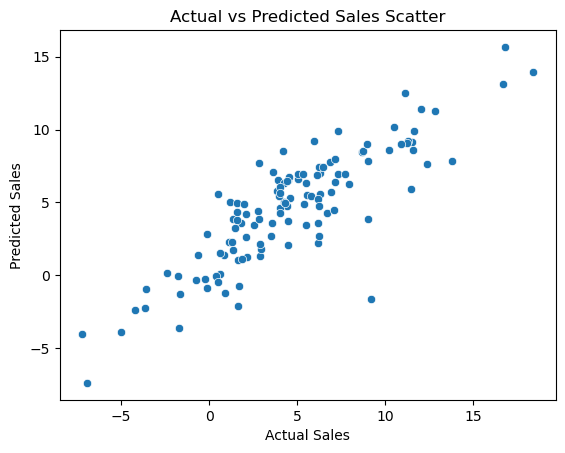

In [66]:
sns.scatterplot(x=data["Sales_A"], y=data["Predicted_Sales"])

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales Scatter")

plt.show()

In [69]:
data[["TV_A","TV_A_adstock","Digital_A","Digital_A_adstock","Radio_A","Radio_A_adstock"]].head(10)

,TV_A,TV_A_adstock,Digital_A,Digital_A_adstock,Radio_A,Radio_A_adstock
0,174.908024,174.908024,171.116023,171.116023,95.236687,95.236687
1,290.142861,377.596873,184.413695,252.860104,96.314286,124.885292
2,246.398788,435.197225,97.700521,198.844563,93.189151,130.654739
3,219.731697,437.330309,66.507789,146.045614,49.612696,88.809118
4,131.203728,349.868883,84.190274,142.608520,21.236529,47.879265
5,131.198904,306.133345,114.066168,171.109576,94.265485,108.629264
6,111.616722,264.683395,172.702215,241.146045,54.254732,86.843511
7,273.235229,405.576927,179.109587,275.568006,97.332386,123.385439
8,220.223002,423.011466,51.042820,161.270022,97.089598,134.105230
9,241.614516,453.120248,126.612095,191.120104,88.240756,128.472325
